In [1]:
%config InlineBackend.figure_format = 'retina'

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

from dv_score import io, lineage, util
from dv_score.viz import viz

In [3]:
sns.set_theme(font_scale=1, style="ticks", palette="tab10", context="talk")

# Clonal lineage tracing
* Identified the DNA barcode in YFP transcripts, saved in column `BC12`
* see bash and python scripts in the [scripts](../scripts/) folder for identifying and extracting lentiviral barcodes

In [4]:
# load clonal lineage tracing data, filtered to clones with multiple OSNs
df_multi = io.load_clones()
n_clones = df_multi.mouse_BC12.nunique()
print(f"Found {n_clones} clones with multiple OSNs")

Found 797 clones with multiple OSNs


## Correlation of DV scores within clone
* Most analyses here are done with 1,000 restarts for convenience, but for the paper we did at least 10,000

In [5]:
df_pair_dv_corr = lineage.pair_corr(df_multi, n_boot=1_000)

100%|██████████████████████████████████████| 1000/1000 [00:02<00:00, 372.41it/s]


Text(0, 0.5, 'Correlation ($\\rho$) of OR DV scores\n between clonally-related OSNs')

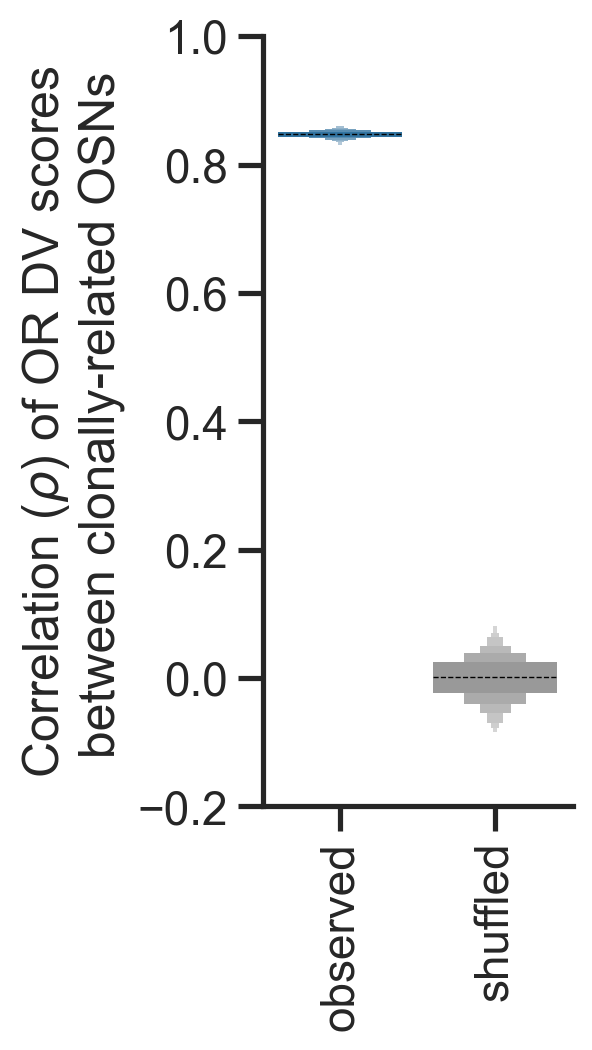

In [6]:
fig, ax = plt.subplots(figsize=(2, 5))
sns.boxenplot(data=df_pair_dv_corr, palette=[plt.cm.tab10(0), "0.6"])
viz.update_boxen(ax)
sns.despine()
plt.xticks(rotation=90)
ax.set_ylim(-0.2, 1)
ax.set_ylabel(
    r"Correlation ($\rho$) of OR DV scores" + "\n between clonally-related OSNs"
)

## Distribution of clones

In [7]:
clonal_mean = df_multi.groupby("BC12").DV_M.mean()
cis = df_multi.groupby("BC12").DV_M.apply(util.get_ci_vect_vectorized)
class_counts = (
    df_multi.groupby("BC12").OR_class.value_counts().unstack().replace(np.nan, 0) > 0
).astype(int)

names = (
    class_counts.Taars.map({0: "", 1: "Taar"})
    + "_"
    + class_counts.class1.map({0: "", 1: "class1"})
    + "_"
    + class_counts.class2.map({0: "", 1: "class2"})
).apply(lambda l: l.strip("_").replace("__", "_"))

clones_use = names.isin(("class2", "class1_class2"))
c2_only_clones = names.index[names == "class2"]
n_clones = clones_use.sum()

c12_clones = names.index[names == "class1_class2"]
xn = np.arange(n_clones)
c2m = clonal_mean.loc[c2_only_clones].values
c2m_order = np.argsort(c2m)
nc = len(c2m_order)

c12m = clonal_mean.loc[c12_clones].values
c12m_order = np.argsort(c12m)

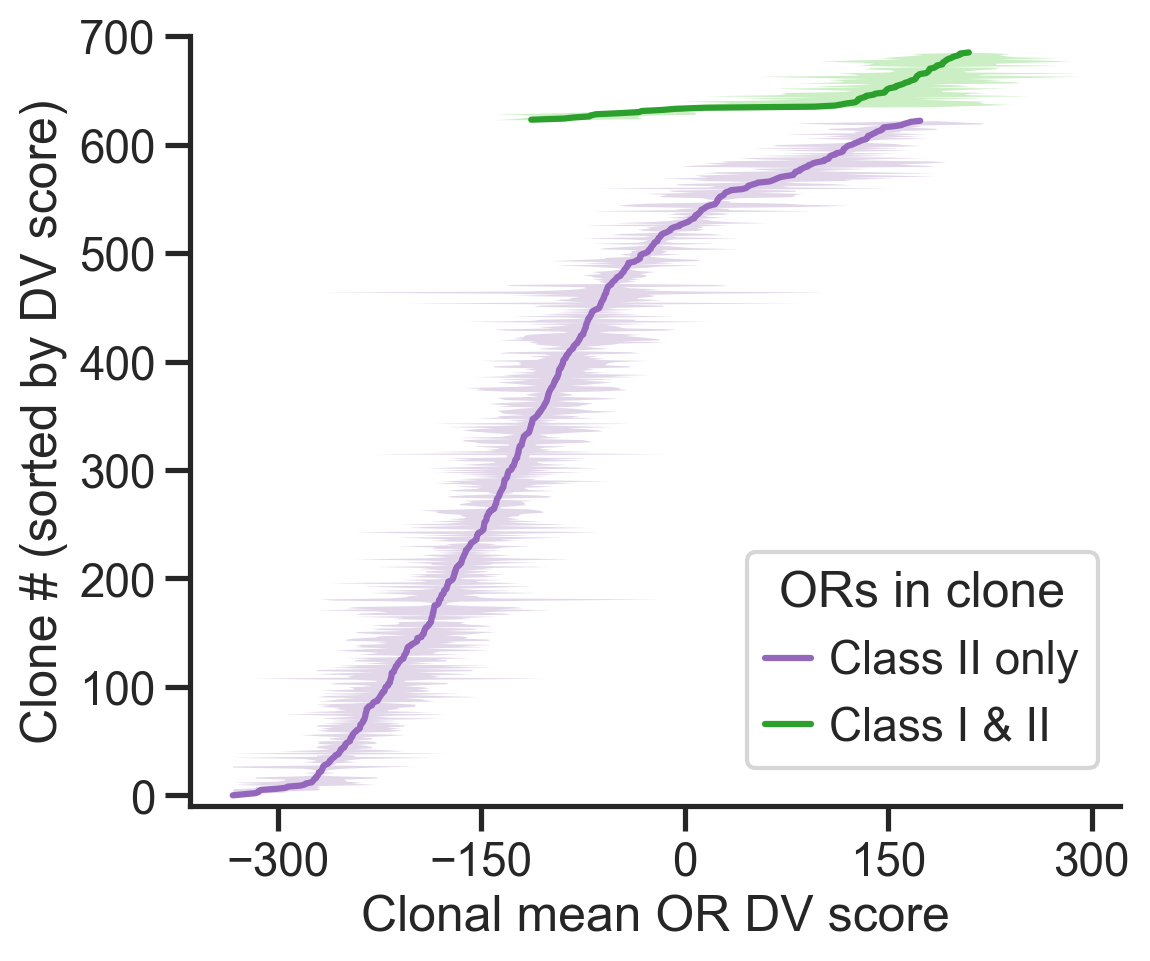

In [8]:
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(c2m[c2m_order], xn[:nc], label="Class II only", color=plt.cm.tab20(8))
ax.fill_betweenx(
    xn[:nc],
    *np.stack(cis.loc[c2_only_clones].values)[c2m_order].T,
    alpha=0.5,
    color=plt.cm.tab20(9),
    lw=0
)

ax.plot(c12m[c12m_order], xn[nc:], label="Class I & II", color=plt.cm.tab20(4))
ax.fill_betweenx(
    xn[nc:],
    *np.stack(cis.loc[c12_clones].values)[c12m_order].T,
    alpha=0.5,
    color=plt.cm.tab20(5),
    lw=0
)
ax.legend(
    title="ORs in clone",
    handlelength=1.0,
    loc="lower right",
    bbox_to_anchor=(1, 0.02),
    handletextpad=0.4,
)
sns.despine()
ax.set_ylabel("Clone # (sorted by DV score)")
ax.set_xlabel("Clonal mean OR DV score")
ax.set_ylim(-10, 700)
ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(150))

## DV score difference within a clone

In [9]:
within_between, df_same, cmat_pct = lineage.within_between_clone(df_multi)

(-0.6, 1.55)

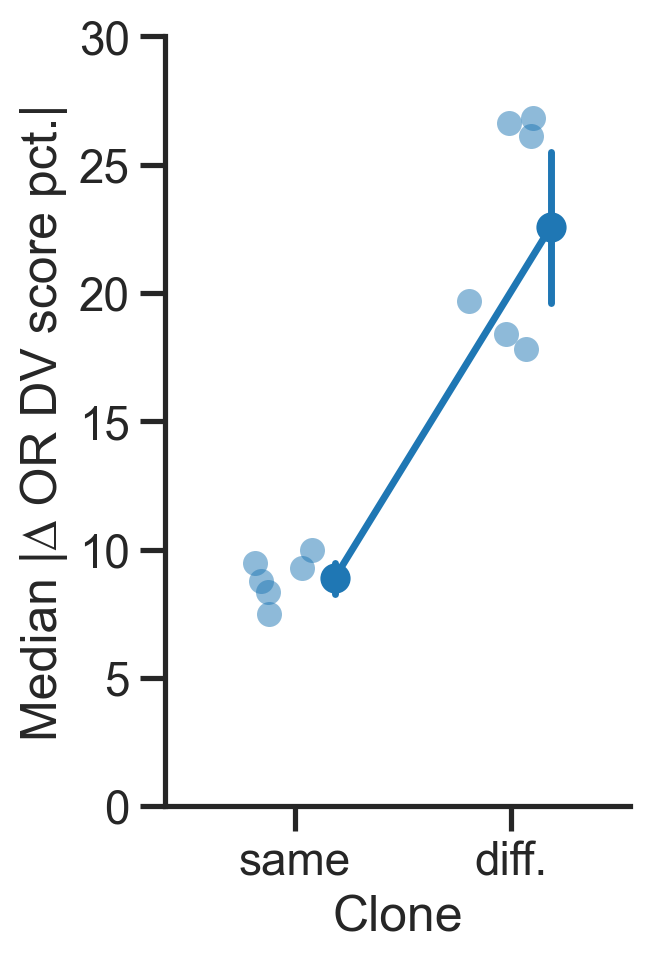

In [10]:
fig, ax = plt.subplots(figsize=(3, 5))
sns.pointplot(
    data=within_between,
    x="same_BC",
    y="pct",
    order=[True, False],
    ax=ax,
    linewidth=2.5,
    ms=9
)
np.random.seed(2024)
viz.offset_pointplot(ax, 0.2)
sns.stripplot(
    data=within_between,
    x="same_BC",
    y="pct",
    order=[True, False],
    ax=ax,
    alpha=0.5,
    jitter=0.2,
    size=9
)
ax.set_ylabel("Median |∆ OR DV score pct.|")
ax.set_xticks([0, 1])
ax.set_xticklabels(["same", "diff."], rotation=0)
ax.set_xlabel("Clone")
sns.despine()
ax.set_ylim(0, 30)
ax.set_xlim(-0.6, 1.55)

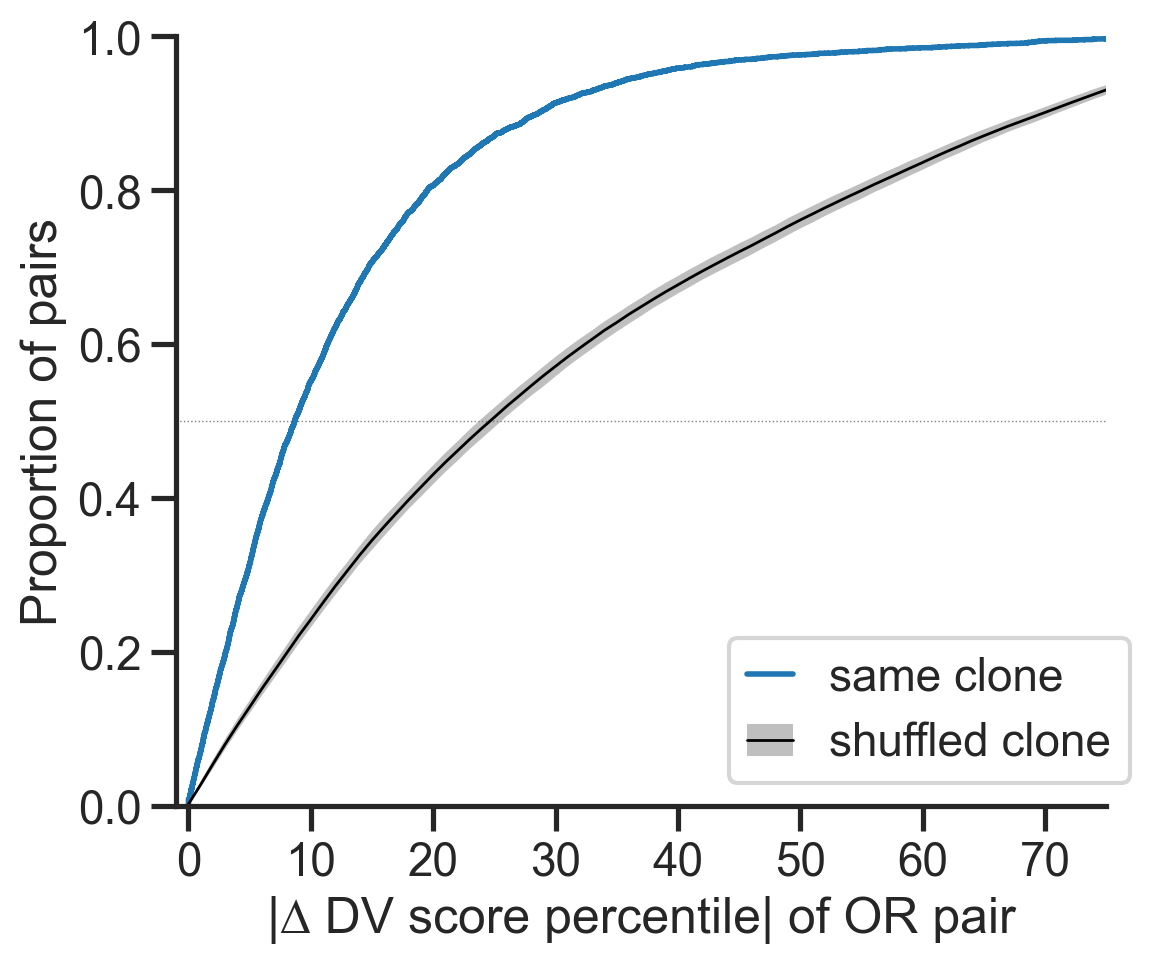

In [11]:
xsz = np.arange(cmat_pct.shape[0])
obs_mean = df_same.groupby("BC12_x").value.mean()
fig, ax = plt.subplots(figsize=(6,5))
(l1,) = ax.step(
    *viz.get_step(df_same.pct, add_max=True), lw=2, label="same clone"
)
o_mean = np.median(obs_mean)
(h2,) = ax.plot(xsz, cmat_pct.mean(1), color="k", label="shuffled", lw=1)
h1 = ax.fill_between(
    xsz,
    *np.percentile(cmat_pct, [2.5, 97.5], axis=1),
    color="0.5",
    alpha=0.5,
    lw=0
)
sns.despine()
ax.set_xlabel("|∆ DV score percentile| of OR pair")
ax.set_ylabel("Proportion of pairs")
ax.legend(
    [l1, (h1, h2)],
    ["same clone", "shuffled clone"],
    handlelength=1,
    loc="lower right",
    bbox_to_anchor=(1.05, 0),
)
ax.set_ylim(0, 1)
ax.set_xlim(-1, 75)
ax.axhline(0.5, ls=":", color="0.5", lw=0.5, zorder=-10)
ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(10))

## Difference from clonal mean

In [12]:
_df = df_multi
clone_mean = _df.groupby("BC12")[["pct", "DV_M"]].mean()
_df_merge = _df.merge(
    clone_mean, left_on="BC12", right_index=True, suffixes=(None, "_mean")
)
_df_merge["pct_delta"] = _df_merge["pct"] - _df_merge["pct_mean"]
_df_merge["DV_delta"] = _df_merge["DV_M"] - _df_merge["DV_M_mean"]

(np.float64(3.186638115798884), np.float64(-0.31695815918036285), np.float64(6.451184491315052))


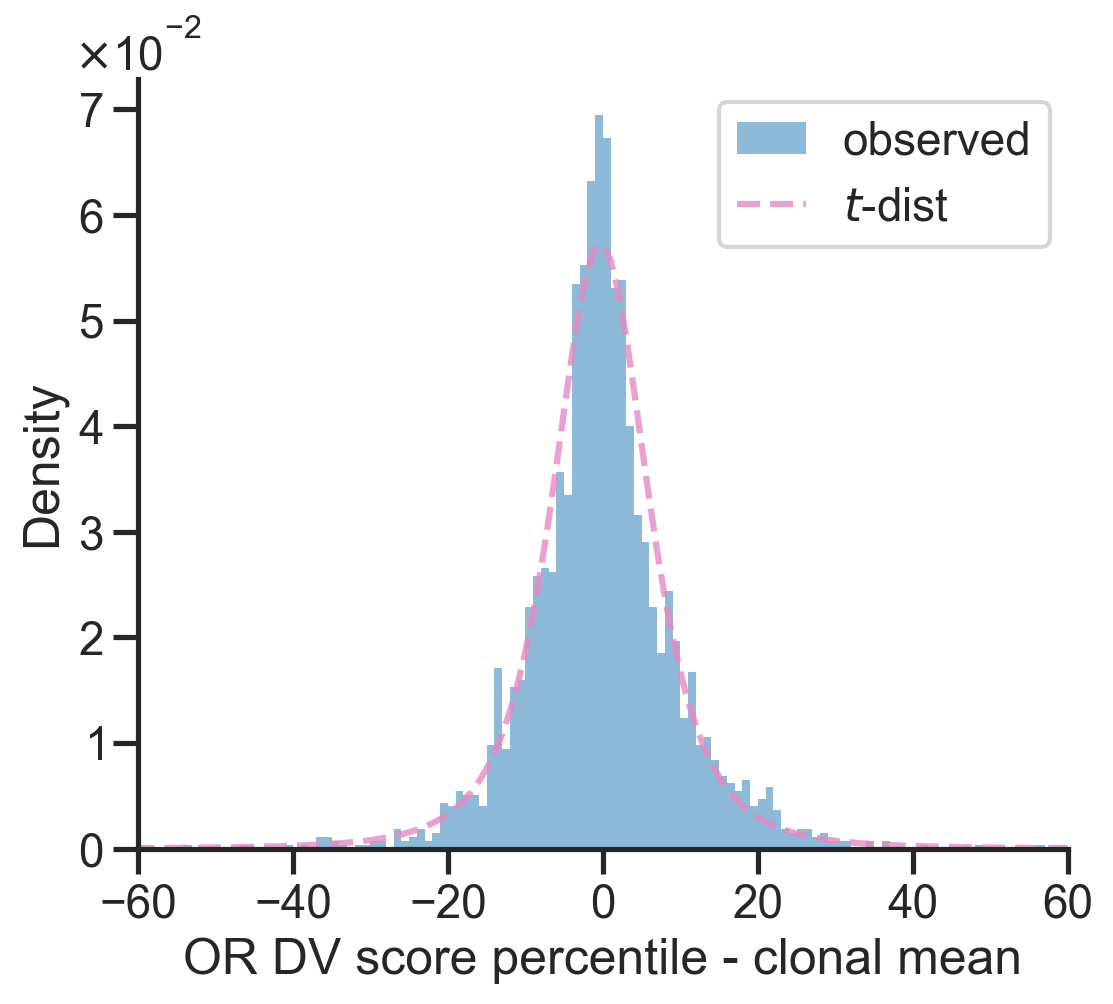

In [13]:
fig, ax = plt.subplots(figsize=(6,5))
deltas = _df_merge["pct_delta"]
bins = np.linspace(-100, 100, 201)
t_color = plt.cm.Set2(3)
params = stats.t.fit(deltas)
print(params)
_x = bins
_y = stats.t.pdf(_x, *params)
ax.hist(
    deltas, bins=bins, lw=0, density=True, label="observed", alpha=0.5, rasterized=True
)
ax.plot(_x, _y, color=t_color, ls="--", label="$t$-dist", alpha=0.8)

ax.set_ylabel("Density")
ax.legend(loc="upper left", bbox_to_anchor=(0.6, 1), handlelength=1.5)
sns.despine()
ax.set_xlabel("OR DV score percentile - clonal mean")
ax.set_xlim(-60, 60)
formatter = mpl.ticker.ScalarFormatter(useMathText=True, useOffset=True)
formatter.set_powerlimits((-5, -4))
ax.yaxis.set_major_formatter(formatter)
ax.get_yaxis().get_offset_text().set_horizontalalignment("center")
sns.despine(left=False)
ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(20))